# Choosing What an AI Model Should Study: Credit Risk Under a Changing Economy

This notebook is a complete, self-contained tour of one research project. You can read it top to
bottom and run every cell yourself. By the end you will understand a real question that sits at the
edge of machine learning research today, and you will have seen the actual data, code, figures, and
results that answer it.

**The one-sentence version.** A new kind of AI model can make predictions about a spreadsheet by
simply *reading* a small table of past examples, instead of being *trained* the usual way. But it can
only read about a thousand rows at a time. When we have hundreds of thousands of past examples,
**which thousand should we show it** — and does a smart choice matter when the world has changed
between the past and now?

**The setting.** We use real loan records. For each past loan we know whether the borrower eventually
paid it back or *defaulted* (failed to pay). We want to predict default for future loans. This is
exactly the problem a bank solves when it decides whether to approve you.

### Roadmap
1. Load and look at real loan data
2. Understand why the passage of *time* makes prediction hard
3. Prepare the data carefully, without accidentally cheating
4. Meet the new kind of model: in-context foundation models (TabPFN and TabFM)
5. Try six different ways of choosing which past loans the model reads
6. Train a panel of ordinary models for comparison, and grade everyone fairly
7. See what the full research study (many datasets, many repeats) concludes

Every code cell is short on purpose. Read the sentence or two above each one, then run it.

## 0. Setup

We load the libraries once, fix a few colors and a random seed (so results are repeatable), and find the data file. A *random seed* is just a starting number for the random-number generator; fixing it means everyone who runs this notebook sees the same 'random' choices.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
BLUE, GREEN, RED, GREY = "#5b7db1", "#4c9f70", "#d1495b", "#cfcfcf"
SEED = 42

# Find the project folder whether the notebook is opened from the repo root or /notebooks.
REPO = Path("/ccn2/u/ishaangp/projects/credit_context_curation")
if not (REPO / "config.yaml").exists():
    here = Path.cwd()
    REPO = here if (here / "config.yaml").exists() else here.parent
DATA  = REPO / "data" / "lending_club.csv"
STATS = REPO / "outputs" / "stats"
FIGS  = REPO / "outputs" / "figures"
print("Project folder :", REPO)
print("Data file found:", DATA.exists())

Project folder : /ccn2/u/ishaangp/projects/credit_context_curation
Data file found: True


A tiny helper for drawing simple box-and-arrow diagrams later. You do not need to understand this cell; it just makes the concept pictures further down.

In [2]:
def _box(ax, x, y, w, h, text, fc, tc="white", fs=10):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.03",
                                linewidth=0, facecolor=fc))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center", color=tc, fontsize=fs)

def _arrow(ax, x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=16,
                                 lw=1.6, color="#444"))

## 1. The data: real loans from Lending Club

Lending Club was an online marketplace that let people take out personal loans. When a loan finishes,
its record tells us whether it was **Fully Paid** or **Charged Off / Default** (the lender gave up on
collecting). We treat "charged off or default" as our target, a `1`, and "fully paid" as `0`.

Each loan is described by a handful of plain-English numbers a lender actually looks at. A few of the
most important ones:

| Feature | Plain meaning |
|---|---|
| `loan_amnt` | how much money was borrowed |
| `int_rate` | the interest rate charged (higher usually means the lender saw more risk) |
| `annual_inc` | the borrower's yearly income |
| `dti` | debt-to-income ratio: monthly debt payments divided by monthly income |
| `fico_range_low` | the borrower's FICO credit score (higher is better credit) |
| `revol_util` | how much of their available credit the borrower is already using |

We also keep the loan's *issue date*, because time is central to this project.

The loader below reads the file, keeps only loans that have actually finished (so we know the true outcome), turns text like `13.5%` into the number `13.5`, and samples at most a few thousand loans per year to keep the notebook fast.

In [3]:
NUMERIC = ["loan_amnt","int_rate","installment","annual_inc","dti","delinq_2yrs",
           "fico_range_low","fico_range_high","open_acc","pub_rec","revol_bal",
           "revol_util","total_acc","mort_acc","pub_rec_bankruptcies"]
FINISHED = ["Fully Paid","Charged Off","Default"]   # only loans that have ended

def to_number(s):
    "Some columns look like '13.5%'. Strip the % sign and turn it into a real number."
    return pd.to_numeric(s.astype(str).str.replace("%","",regex=False), errors="coerce")

def load_lending_club(max_per_year=5000):
    cols = NUMERIC + ["issue_d","loan_status","home_ownership"]
    df = pd.read_csv(DATA, usecols=cols, low_memory=False)
    df["date"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
    df = df[df["date"].notna() & df["loan_status"].isin(FINISHED)].copy()
    df["default"] = df["loan_status"].isin(["Charged Off","Default"]).astype(int)
    df["year"] = df["date"].dt.year
    df = df.groupby("year", group_keys=False).apply(                       # at most max_per_year per year
            lambda g: g.sample(min(len(g), max_per_year), random_state=SEED))
    df = df.sort_values("date").reset_index(drop=True)
    X = pd.DataFrame({c: to_number(df[c]) for c in NUMERIC})               # the numeric features
    home = df["home_ownership"].where(df["home_ownership"].isin(["RENT","OWN","MORTGAGE"]), "OTHER")
    X = pd.concat([X, pd.get_dummies(home, prefix="home").astype(int)], axis=1)   # yes/no home columns
    return X.reset_index(drop=True), df["default"].reset_index(drop=True), df["date"].reset_index(drop=True), df

X_all, y_all, dates_all, raw = load_lending_club()
print(f"Loaded {len(X_all):,} loans | {X_all.shape[1]} features | years {raw.year.min()}-{raw.year.max()}")

Loaded 51,529 loans | 19 features | years 2007-2018


Here are a few real rows. Each line is one loan. The last column, `default`, is what we are trying to predict.

In [4]:
raw[["date","loan_amnt","int_rate","annual_inc","fico_range_low","dti","loan_status","default"]].head(8)

,date,loan_amnt,int_rate,annual_inc,fico_range_low,dti,loan_status,default
0,2007-06-01,7500.0,13.75,22000.0,660.0,14.29,Fully Paid,0
1,2007-07-01,5000.0,7.43,150000.0,775.0,0.00,Fully Paid,0
2,2007-07-01,5300.0,8.38,74000.0,795.0,14.37,Fully Paid,0
3,2007-07-01,5000.0,7.43,85000.0,785.0,0.31,Fully Paid,0
4,2007-07-01,5000.0,8.07,180000.0,740.0,5.55,Fully Paid,0
5,2007-07-01,5000.0,11.22,80000.0,670.0,1.21,Fully Paid,0
6,2007-07-01,1200.0,11.54,20000.0,660.0,2.04,Fully Paid,0
7,2007-07-01,5400.0,7.75,8000.0,760.0,3.00,Fully Paid,0


### 1a. A first look: three facts that shape the whole project

The three pictures below each carry a lesson:

1. **Defaults are rare.** Most loans get paid back. This *class imbalance* means a lazy model that
   always predicts "paid" would be right most of the time while being useless. We will need metrics
   that are not fooled by this.
2. **The default rate drifts over time.** The fraction of loans that go bad rises and falls with the
   economy. A pattern learned in one year may not hold in another. This drift is the reason the whole
   project exists.
3. **Some information is missing.** Real data has holes. We will have to fill them in honestly.

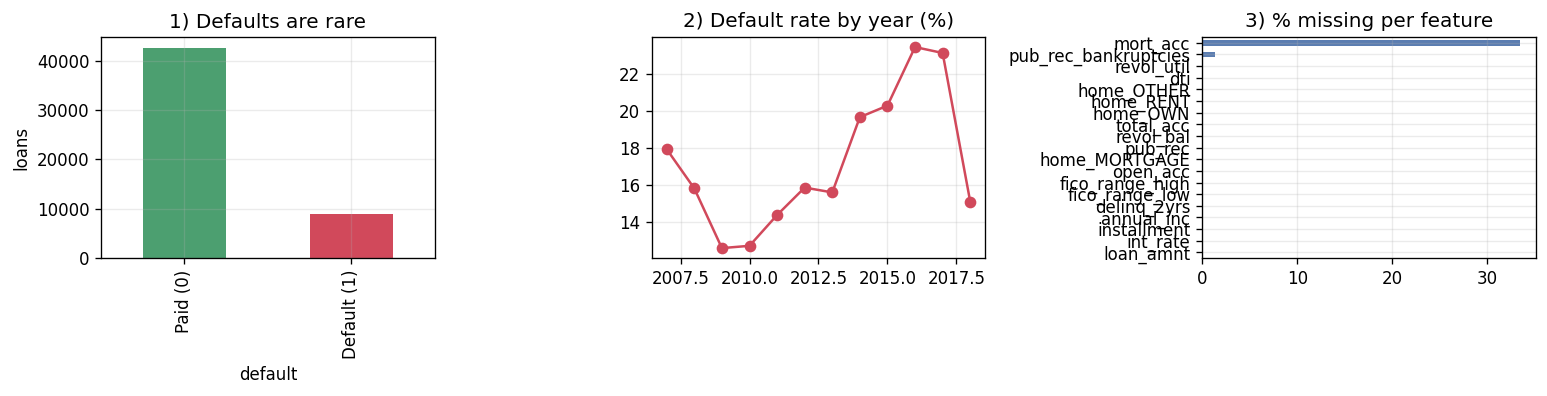

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
y_all.value_counts().sort_index().rename({0:"Paid (0)",1:"Default (1)"}).plot.bar(
    ax=ax[0], color=[GREEN, RED]); ax[0].set_title("1) Defaults are rare"); ax[0].set_ylabel("loans")
raw.groupby("year")["default"].mean().mul(100).plot(marker="o", color=RED, ax=ax[1])
ax[1].set_title("2) Default rate by year (%)"); ax[1].set_xlabel("")
X_all.isna().mean().mul(100).sort_values().plot.barh(ax=ax[2], color=BLUE)
ax[2].set_title("3) % missing per feature")
plt.tight_layout(); plt.show()

How rare is 'rare'? Exactly this rare:

In [6]:
counts = y_all.value_counts().sort_index()
pd.DataFrame({"loans": counts.values, "share_%": (100*counts/len(y_all)).round(1).values},
             index=["Paid (0)", "Default (1)"])

,loans,share_%
Paid (0),42635,82.7
Default (1),8894,17.3


### 1b. What the features look like

Distributions of four intuitive features (trimmed at the 99th percentile so a few extreme values do not squash the picture). Income is very skewed; most people earn a modest amount and a few earn a great deal.

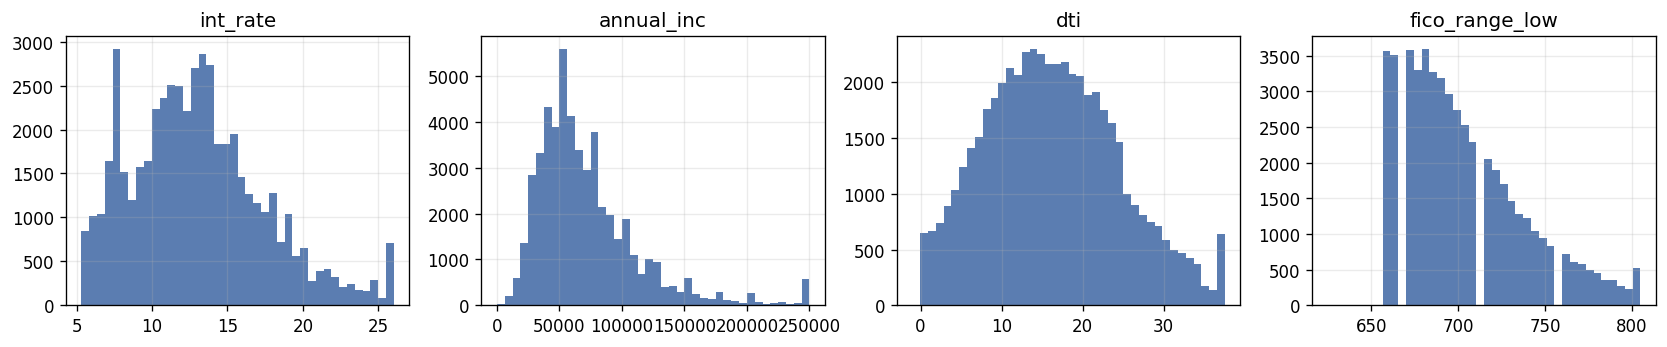

,int_rate,annual_inc,dti,fico_range_low
count,51529.0,51529.0,51511.0,51529.0
mean,13.0,73172.6,16.5,703.2
std,4.5,61839.1,10.3,34.7
min,5.3,0.0,-1.0,625.0
25%,9.9,44000.0,10.2,675.0
50%,12.7,61800.0,15.8,695.0
75%,15.6,88000.0,21.9,725.0
max,31.0,6000000.0,751.2,845.0


In [7]:
feats = ["int_rate","annual_inc","dti","fico_range_low"]
fig, ax = plt.subplots(1, 4, figsize=(14, 3))
for a, c in zip(ax, feats):
    X_all[c].clip(upper=X_all[c].quantile(0.99)).hist(bins=40, color=BLUE, ax=a); a.set_title(c)
plt.tight_layout(); plt.show()
X_all[feats].describe().round(1)

### 1c. Does the data behave the way common sense expects?

A good sanity check: people with **lower credit scores should default more often**. If the data did
not show this, we would suspect a bug. The bars below group loans by FICO score and show the default
rate in each group. The downward slope is exactly what we hope to see.

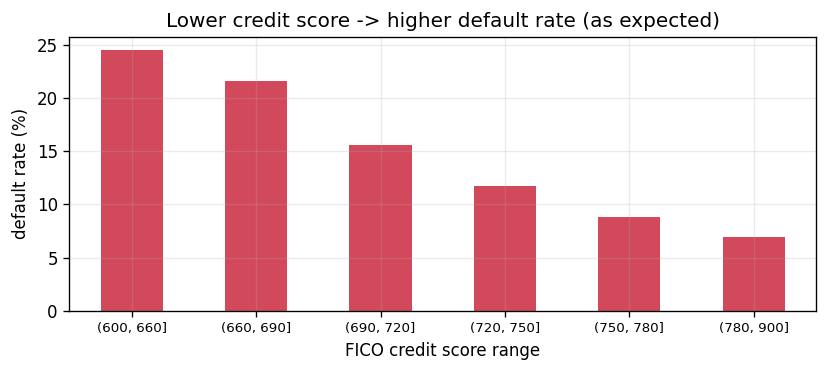

In [8]:
bucket = pd.cut(X_all["fico_range_low"], bins=[600,660,690,720,750,780,900])
rate = (y_all.groupby(bucket).mean()*100)
fig, ax = plt.subplots(figsize=(7, 3.2))
rate.plot.bar(ax=ax, color=RED)
ax.set_ylabel("default rate (%)"); ax.set_xlabel("FICO credit score range")
ax.set_title("Lower credit score -> higher default rate (as expected)")
plt.xticks(rotation=0, fontsize=8); plt.tight_layout(); plt.show()

### 1d. How the features relate to each other

This heatmap shows the *correlation* between every pair of features. Red means two features rise
together; blue means one rises as the other falls. For example `fico_range_low` and `fico_range_high`
are almost perfectly correlated (they are two ends of the same score), and `loan_amnt` moves with
`installment` (bigger loans have bigger monthly payments). Seeing these relationships helps us trust
that the columns mean what we think they mean.

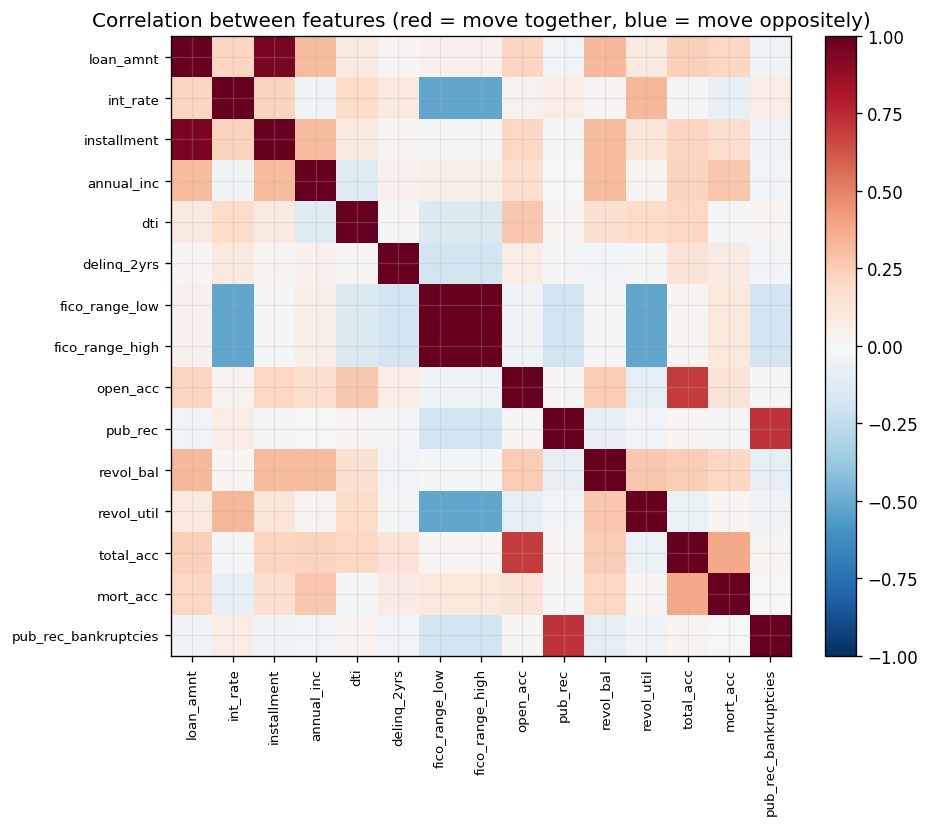

In [9]:
corr = X_all[NUMERIC].corr()
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
ax.set_title("Correlation between features (red = move together, blue = move oppositely)")
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

## 2. Why time makes this hard

A machine learning model is only useful if it works on data it has never seen. In the real world, the
data it has never seen is the **future**. So the honest way to test a model is: let it learn from the
past, then ask it to predict a later period it was never shown.

We split our loans into two time periods:

- **POOL** (years 2013-2016): the history the model is allowed to learn from.
- **TEST** (years 2017-2018): the future we must predict. The model never sees these outcomes until
  we grade it.

This is stricter than shuffling all the loans together and splitting randomly. A random split would
let the model peek at 2018 while predicting 2018 — a subtle form of cheating that makes results look
better than they really are. Splitting by time forbids that.

In [10]:
POOL_YEARS, TEST_YEARS = [2013,2014,2015,2016], [2017,2018]
is_pool = raw.year.isin(POOL_YEARS).to_numpy()
is_test = raw.year.isin(TEST_YEARS).to_numpy()

Xp_raw = X_all[is_pool].reset_index(drop=True)
yp     = y_all[is_pool].reset_index(drop=True)
dp     = dates_all[is_pool].reset_index(drop=True)
Xt_raw = X_all[is_test].reset_index(drop=True)
yt     = y_all[is_test].reset_index(drop=True)
print(f"POOL: {len(Xp_raw):,} loans (2013-16)   |   TEST: {len(Xt_raw):,} loans (2017-18)")

POOL: 20,000 loans (2013-16)   |   TEST: 10,000 loans (2017-18)


A timeline makes the split concrete. Blue years are the history we may learn from; red years are the future we must predict; grey years are set aside for this particular split.

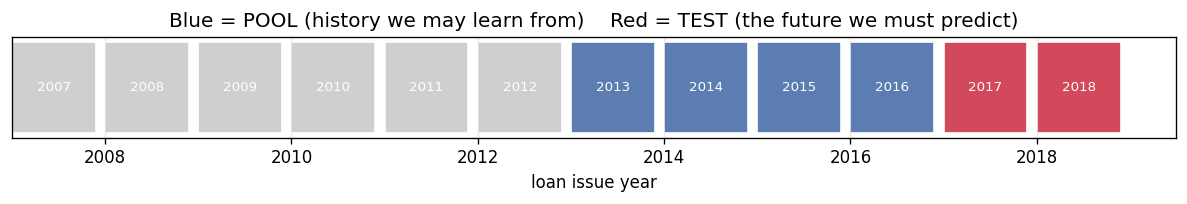

In [11]:
fig, ax = plt.subplots(figsize=(10, 1.8))
for yr in sorted(raw.year.unique()):
    c = BLUE if yr in POOL_YEARS else (RED if yr in TEST_YEARS else GREY)
    ax.barh(0, 0.9, left=yr, color=c, edgecolor="white")
    ax.text(yr+0.45, 0, str(yr), ha="center", va="center", color="white", fontsize=8)
ax.set_yticks([]); ax.set_xlabel("loan issue year")
ax.set_title("Blue = POOL (history we may learn from)    Red = TEST (the future we must predict)")
plt.tight_layout(); plt.show()

Notice that the two periods are not identical: the default rate is different between them. That gap is the *drift* the model has to survive.

In [12]:
pd.DataFrame({
    "loans":     [len(Xp_raw), len(Xt_raw)],
    "default_%": [round(100*yp.mean(),2), round(100*yt.mean(),2)],
}, index=["POOL (2013-16)","TEST (2017-18)"])

,loans,default_%
POOL (2013-16),20000,19.74
TEST (2017-18),10000,19.11


## 3. Preparing the data without cheating

Two small chores stand between raw data and a model:

1. **Fill in missing values.** Where a number is missing, we substitute the *median* (middle value)
   of that column. Crucially, we compute that median from the **POOL only**. If we used the whole
   dataset, information from the 2017-2018 future would leak backward into how we clean the 2013-2016
   past. That is the cheating we are avoiding.
2. **Put every feature on the same scale.** Income is in tens of thousands; interest rate is a small
   percentage. Many models behave better when features are reshaped to a common, bell-shaped scale.
   We use a *quantile transformer*, and again we **fit it on the POOL and merely apply it to the
   TEST**.

The rule of thumb: *anything the model learns from must be measured on the past only.*

In [13]:
def preprocess(pool_X, test_X):
    med = pool_X.median(numeric_only=True)                 # medians learned from POOL only
    pool_X = pool_X.fillna(med).fillna(0.0).astype(float)
    test_X = test_X.fillna(med).fillna(0.0).astype(float)  # TEST is filled with POOL medians
    qt = QuantileTransformer(output_distribution="normal",
                             n_quantiles=min(1000, len(pool_X)), random_state=42)
    pool_s = pd.DataFrame(qt.fit_transform(pool_X), columns=pool_X.columns)   # fit on POOL
    test_s = pd.DataFrame(qt.transform(test_X),     columns=test_X.columns)   # apply to TEST
    return pool_s, test_s

Xp, Xt = preprocess(Xp_raw, Xt_raw)
print("Preprocessing done. Feature columns:", list(Xp.columns))

Preprocessing done. Feature columns: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'home_MORTGAGE', 'home_OTHER', 'home_OWN', 'home_RENT']


Here is the reshaping in action. On the left, raw annual income is bunched near zero with a long tail. On the right, after the transform, the same feature is spread into a tidy bell shape that models find easier to use.

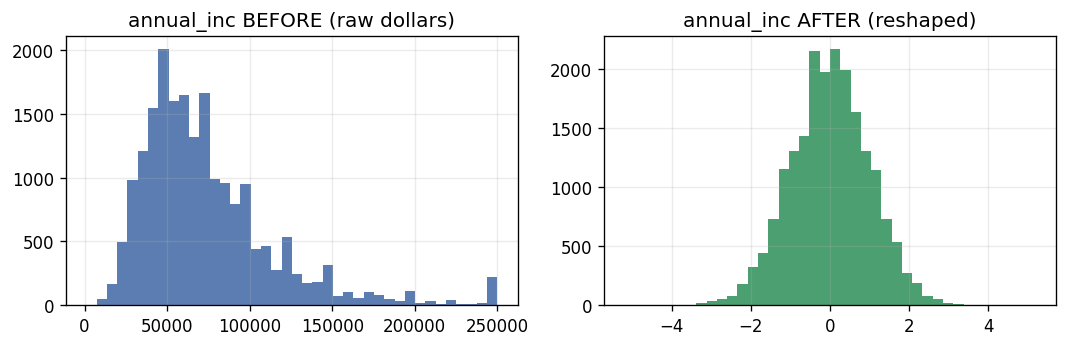

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
Xp_raw["annual_inc"].clip(upper=Xp_raw["annual_inc"].quantile(0.99)).hist(bins=40, color=BLUE, ax=ax[0])
ax[0].set_title("annual_inc BEFORE (raw dollars)")
Xp["annual_inc"].hist(bins=40, color=GREEN, ax=ax[1]); ax[1].set_title("annual_inc AFTER (reshaped)")
plt.tight_layout(); plt.show()

## 4. A new kind of model: in-context foundation models

To understand the research question we need to understand the models.

**The traditional way (for example, decision trees or logistic regression).** You take a big pile of
past examples and *train*: the model slowly adjusts its internal settings until it fits the data.
Training can take minutes to hours, and it produces one fixed model.

**The new way (TabPFN and TabFM).** These are *foundation models for tables*. They were pre-trained
once, by their creators, on enormous numbers of synthetic prediction tasks. After that, they do not
train on your data at all. You simply hand them a small table of labeled examples, called a
**context**, and they immediately answer questions about new rows. Learning happens by *reading*, not
by *training*. This trick is called **in-context learning**.

The diagram below contrasts the two.

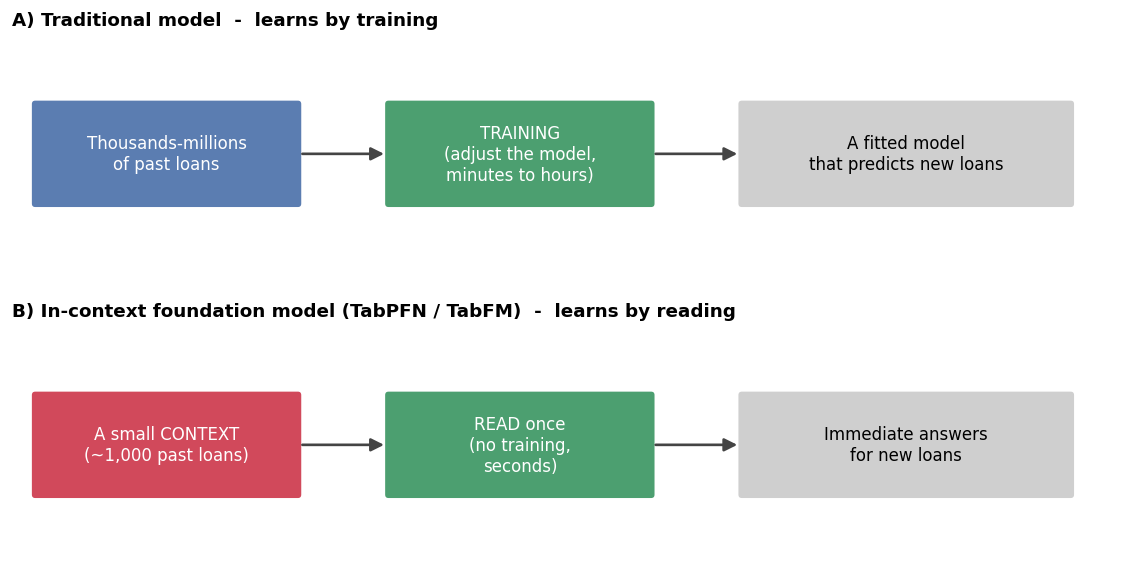

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(9.5, 5.0))
for a in ax: a.set_xlim(0,10); a.set_ylim(0,2.2); a.axis("off")
ax[0].set_title("A) Traditional model  -  learns by training", loc="left", fontsize=11, weight="bold")
_box(ax[0], 0.2,0.7,2.4,0.9,"Thousands-millions\nof past loans", BLUE)
_box(ax[0], 3.4,0.7,2.4,0.9,"TRAINING\n(adjust the model,\nminutes to hours)", GREEN)
_box(ax[0], 6.6,0.7,3.0,0.9,"A fitted model\nthat predicts new loans", GREY, tc="black")
_arrow(ax[0],2.6,1.15,3.4,1.15); _arrow(ax[0],5.8,1.15,6.6,1.15)
ax[1].set_title("B) In-context foundation model (TabPFN / TabFM)  -  learns by reading", loc="left", fontsize=11, weight="bold")
_box(ax[1], 0.2,0.7,2.4,0.9,"A small CONTEXT\n(~1,000 past loans)", RED)
_box(ax[1], 3.4,0.7,2.4,0.9,"READ once\n(no training,\nseconds)", GREEN)
_box(ax[1], 6.6,0.7,3.0,0.9,"Immediate answers\nfor new loans", GREY, tc="black")
_arrow(ax[1],2.6,1.15,3.4,1.15); _arrow(ax[1],5.8,1.15,6.6,1.15)
plt.tight_layout(); plt.show()

**Why use two of them?** We test **TabPFN** and **TabFM**, two independently built foundation models.
If both show the same behavior on the same contexts, we can be more confident that what we are seeing
is a general property of in-context learning, not a quirk of one particular model.

**The catch, and the research question.** These models can only read a limited context, roughly
**1,000 rows**. But our history has far more loans than that. So we are forced to choose: out of all
the past loans, **which ~1,000 do we put in the context?** That choice is the subject of this project.

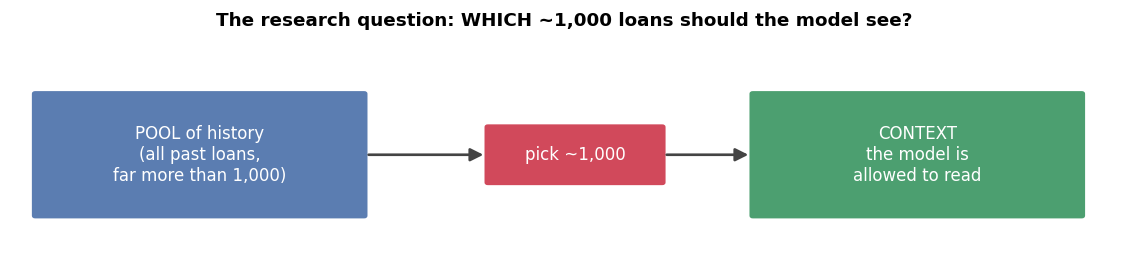

In [16]:
fig, ax = plt.subplots(figsize=(9.5, 2.4)); ax.set_xlim(0,10); ax.set_ylim(0,2.4); ax.axis("off")
_box(ax, 0.2,0.5,3.0,1.3,"POOL of history\n(all past loans,\nfar more than 1,000)", BLUE)
_box(ax, 4.3,0.85,1.6,0.6,"pick ~1,000", RED)
_box(ax, 6.7,0.5,3.0,1.3,"CONTEXT\nthe model is\nallowed to read", GREEN)
_arrow(ax,3.2,1.15,4.3,1.15); _arrow(ax,5.9,1.15,6.7,1.15)
ax.set_title("The research question: WHICH ~1,000 loans should the model see?", fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

## 5. Six ways to choose the context

We compare six strategies for picking the context out of the POOL. Each encodes a different guess
about what makes an example worth showing the model.

- **random** - pick loans uniformly at random. This is the control group: it has no opinion, so any
  other strategy has to beat it to be worth anything.
- **most_recent** - pick the newest loans before the test period. The bet: recent history resembles
  the near future more than old history does.
- **class_balanced** - pick roughly equal numbers of paid and defaulted loans. Because defaults are
  rare, a random context can contain very few of them; this strategy makes sure the model sees plenty.
- **economically_similar** - find the past year whose overall conditions (interest rates, default
  rate, credit quality) most resemble the test period, and draw the context from that year.
- **high_confidence** - train a quick throwaway model, then keep the loans it is *least* sure about
  (predicted probability nearest 50%). The bet: borderline cases teach the decision boundary best.
- **diverse** - spread the picks across the feature space using clustering, so many *kinds* of
  borrowers are represented rather than many near-duplicates.

The code below defines all six as small functions that each return the row numbers they picked.

In [17]:
FICO = Xp.columns.get_loc("fico_range_low")   # column positions used by economically_similar
RATE = Xp.columns.get_loc("int_rate")
N_CONTEXT = 400                               # small context for a quick, readable live demo

def pick_random(seed=SEED):
    return np.random.default_rng(seed).choice(len(Xp), N_CONTEXT, replace=False)

def pick_most_recent(seed=SEED):
    return np.argsort(dp.to_numpy())[-N_CONTEXT:]                       # the latest dates

In [18]:
def pick_class_balanced(seed=SEED):
    rng = np.random.default_rng(seed)
    pos, neg = np.flatnonzero(yp.to_numpy()==1), np.flatnonzero(yp.to_numpy()==0)
    k = min(len(pos), N_CONTEXT//2); j = min(len(neg), N_CONTEXT-k)
    return rng.permutation(np.r_[rng.choice(pos,k,False), rng.choice(neg,j,False)])

def pick_economically_similar(seed=SEED):
    years = pd.to_datetime(dp).dt.year
    target = np.array([Xt.iloc[:,RATE].mean(), yt.mean(), Xt.iloc[:,FICO].mean()])   # the test period's "weather"
    def summary(mask): return np.array([Xp.loc[mask].iloc[:,RATE].mean(), yp[mask].mean(), Xp.loc[mask].iloc[:,FICO].mean()])
    best = min(years.unique(), key=lambda yr: np.linalg.norm(summary((years==yr).to_numpy()) - target))
    pos = np.flatnonzero((years==best).to_numpy())
    return np.random.default_rng(seed).choice(pos, min(N_CONTEXT,len(pos)), replace=False)

In [19]:
def pick_high_confidence(seed=SEED):
    quick = HistGradientBoostingClassifier(max_iter=100, random_state=seed).fit(Xp, yp)
    unsure = np.abs(quick.predict_proba(Xp)[:,1] - 0.5)                 # distance from a 50/50 guess
    return np.argsort(unsure)[:N_CONTEXT]                               # keep the least-sure loans

def pick_diverse(seed=SEED):
    km = KMeans(n_clusters=N_CONTEXT, n_init=1, random_state=seed).fit(Xp.to_numpy())
    nearest = np.unique(km.transform(Xp.to_numpy()).argmin(axis=0))     # one loan closest to each cluster center
    if len(nearest) < N_CONTEXT:
        rest = np.setdiff1d(np.arange(len(Xp)), nearest)
        nearest = np.r_[nearest, np.random.default_rng(seed).choice(rest, N_CONTEXT-len(nearest), False)]
    return nearest

PICKERS = {"random":pick_random, "most_recent":pick_most_recent, "class_balanced":pick_class_balanced,
           "economically_similar":pick_economically_similar, "high_confidence":pick_high_confidence,
           "diverse":pick_diverse}
contexts = {name: np.asarray(fn()) for name, fn in PICKERS.items()}
print(f"Built a {N_CONTEXT}-loan context for each of the {len(contexts)} strategies.")

Built a 400-loan context for each of the 6 strategies.


### What each strategy actually selects

The picture below is a *map* of the entire pool. We squeezed all the features down to two dimensions
using PCA (a standard way to draw high-dimensional data on a flat page); each grey dot is one past
loan. The red dots are the loans a given strategy chose. Notice how different the strategies look:
`most_recent` and `economically_similar` grab tight clumps, `diverse` spreads out evenly, and
`high_confidence` hugs a particular region.

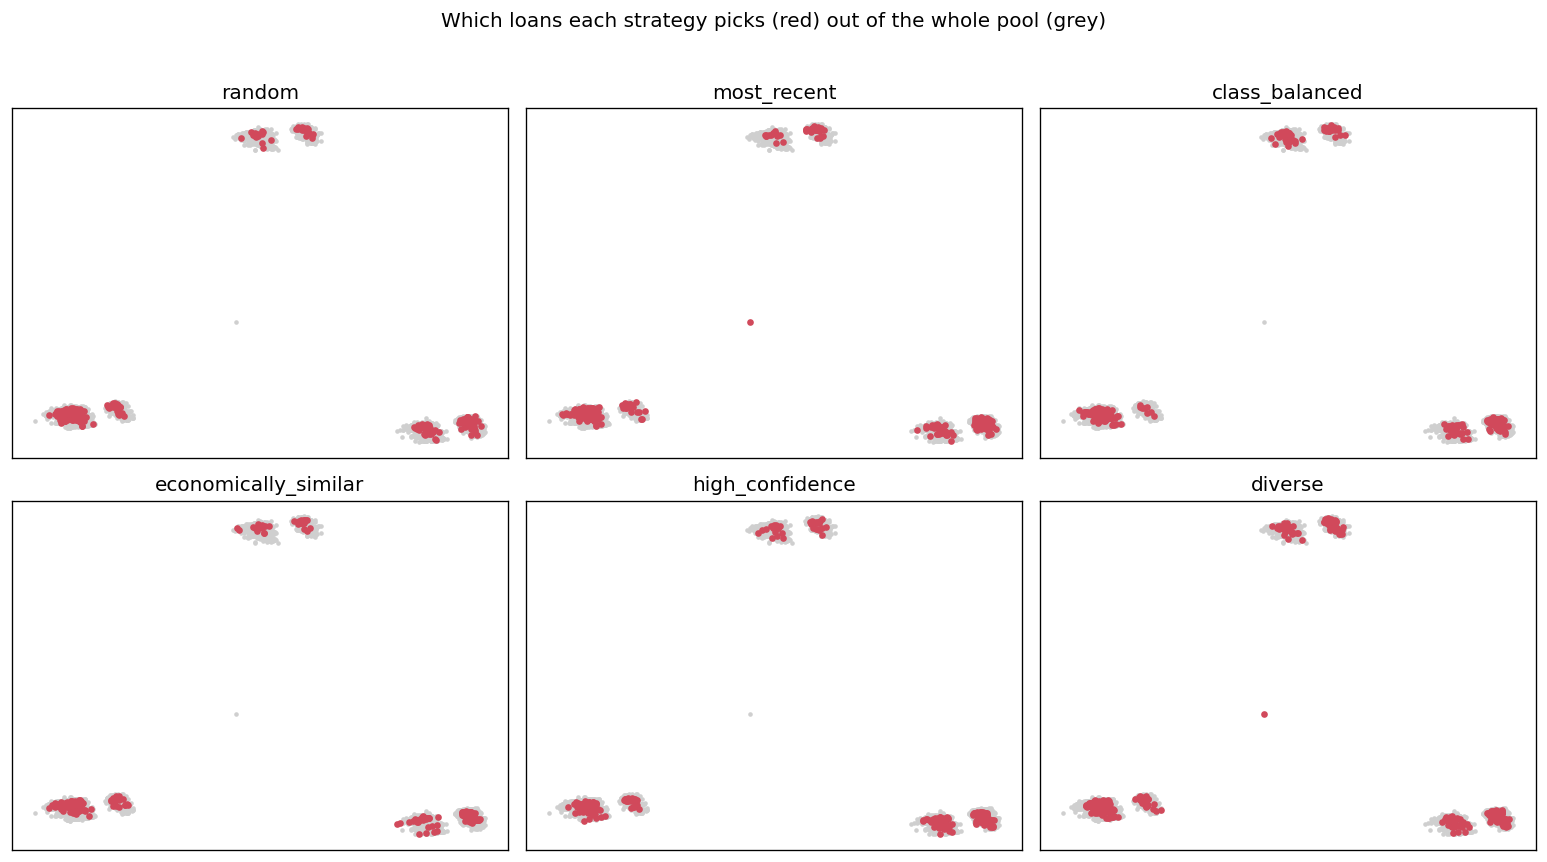

In [20]:
proj = PCA(n_components=2, random_state=0).fit_transform(Xp.to_numpy())
fig, ax = plt.subplots(2, 3, figsize=(13, 7))
for a, s in zip(ax.ravel(), contexts):
    a.scatter(proj[:,0], proj[:,1], s=3, color=GREY)
    idx = contexts[s]; a.scatter(proj[idx,0], proj[idx,1], s=9, color=RED)
    a.set_title(s); a.set_xticks([]); a.set_yticks([])
fig.suptitle("Which loans each strategy picks (red) out of the whole pool (grey)", y=1.02)
plt.tight_layout(); plt.show()

### A warning hidden inside `high_confidence`

`high_confidence` sounds clever, but it has a trap. By keeping only the loans a quick model found
*confusing*, it selects an unusual slice of the data where the normal relationships can break.

Look at the correlation between credit score and default. Across the whole pool it is **negative** (as
expected: lower score, more default). But inside the `high_confidence` context the correlation can
**flip to positive** — the exact opposite of reality. A model that reads such a context can learn the
relationship upside-down.

corr(FICO, default)  -  whole pool: -0.093   |   high_confidence context: +0.098


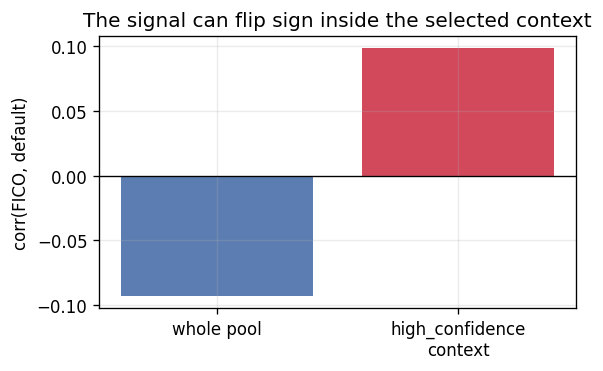

In [21]:
whole_pool = np.corrcoef(Xp["fico_range_low"], yp)[0, 1]
hc = contexts["high_confidence"]
in_context = np.corrcoef(Xp["fico_range_low"].iloc[hc], yp.iloc[hc])[0, 1]
print(f"corr(FICO, default)  -  whole pool: {whole_pool:+.3f}   |   high_confidence context: {in_context:+.3f}")

plt.figure(figsize=(5, 3.2))
plt.bar(["whole pool", "high_confidence\ncontext"], [whole_pool, in_context], color=[BLUE, RED])
plt.axhline(0, color="k", lw=0.8); plt.ylabel("corr(FICO, default)")
plt.title("The signal can flip sign inside the selected context")
plt.tight_layout(); plt.show()

## 6. Training a panel of models, then grading everyone

Now we put the contexts to work. We compare two *kinds* of learner on the **same** context each time,
so the only thing that changes is the learner, never the data it sees.

**Ordinary models that train on the context.** These are the familiar tools a data team would reach
for. We include a broad panel so the comparison is not a straw man:

- Regressions: `LR (logistic)` and `ElasticNet-LR` (a regularized cousin).
- Tree ensembles: `RandomForest`, `ExtraTrees`, `HistGBM`, `XGBoost`, `LightGBM`.

**The foundation model that reads the context.** `TabPFN`, run live on a GPU, simply reads the same
400 loans and predicts — no training.

First, the grading. We use four numbers, because a single number can hide problems:

- **AUC** (Area Under the ROC Curve): if you pick one real defaulter and one real payer at random,
  AUC is the chance the model gives the defaulter the higher risk score. `0.5` is coin-flip guessing;
  `1.0` is perfect. This metric is not fooled by rare defaults, which is why it is our headline number.
- **AP** (Average Precision): focuses on how well the model finds the rare defaulters specifically.
- **Brier score**: are the predicted probabilities *honest*? It measures the gap between predicted
  probability and reality. Lower is better.
- **ECE** (Expected Calibration Error): another honesty check. If the model says "20% chance of
  default" for a group of loans, about 20% of them should actually default. Lower is better.

In [22]:
def ece(y, p, bins=10):
    "Expected Calibration Error: are the predicted probabilities honest, on average?"
    y, p = np.asarray(y), np.asarray(p); edges = np.linspace(0, 1, bins+1); err = 0.0
    for i in range(bins):
        hi = edges[i+1] + (1e-9 if i == bins-1 else 0)
        m = (p >= edges[i]) & (p < hi)
        if m.sum(): err += m.sum() * abs(y[m].mean() - p[m].mean())
    return err / len(y)

def grade(y, p):
    return {"AUC":roc_auc_score(y,p), "AP":average_precision_score(y,p),
            "Brier":brier_score_loss(y,p), "ECE":ece(y,p)}

To keep the live demo quick we grade on a fixed random sample of test loans.

In [23]:
ridx = np.random.default_rng(0).choice(len(Xt), min(3000, len(Xt)), replace=False)
Xt_s, yt_s = Xt.iloc[ridx], yt.iloc[ridx].to_numpy()
print(f"Grading everyone on the same {len(Xt_s):,} held-out test loans.")

Grading everyone on the same 3,000 held-out test loans.


The conventional model panel, defined once as a dictionary so it is easy to read and extend.

In [24]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

def build_models(seed=SEED):
    "Two regressions plus five tree ensembles, each trained on a curated context."
    return {
        "LR (logistic)": LogisticRegression(max_iter=1000),
        "ElasticNet-LR": LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5, max_iter=2000),
        "RandomForest":  RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1),
        "ExtraTrees":    ExtraTreesClassifier(n_estimators=200, random_state=seed, n_jobs=-1),
        "HistGBM":       HistGradientBoostingClassifier(max_iter=200, random_state=seed),
        "XGBoost":       XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
                                       colsample_bytree=0.8, tree_method="hist", device="cpu",
                                       eval_metric="logloss", random_state=seed),
        "LightGBM":      LGBMClassifier(n_estimators=200, learning_rate=0.05, subsample=0.8,
                                        colsample_bytree=0.8, random_state=seed, verbosity=-1),
    }
print("Panel:", ", ".join(build_models().keys()))

Panel: LR (logistic), ElasticNet-LR, RandomForest, ExtraTrees, HistGBM, XGBoost, LightGBM


Train every model on every context and record its four grades. (This is the slowest cell; it fits seven models across six contexts.)

In [25]:
def train_on_context(idx):
    "Fit every conventional model on one context and grade it on the test sample."
    Xc, yc = Xp.iloc[idx], yp.iloc[idx]
    if yc.nunique() < 2:                                  # a context with only one class cannot rank; give it chance-level
        const = np.full(len(yt_s), float(yc.iloc[0] == 1))
        return {name: grade(yt_s, const) for name in build_models()}
    out = {}
    for name, model in build_models().items():
        model.fit(Xc, yc)
        out[name] = grade(yt_s, model.predict_proba(Xt_s)[:, 1])
    return out

demo = {s: train_on_context(idx) for s, idx in contexts.items()}
print(f"Trained {len(build_models())} models on all {len(contexts)} contexts.")

Trained 7 models on all 6 contexts.


Now the foundation model. `TabPFN` reads each context and predicts, live on a GPU. If no GPU is available this cell simply skips itself, and the full-study section below still has the real foundation-model numbers.

In [26]:
tabpfn_auc = {}
try:
    import torch
    from tabpfn import TabPFNClassifier
    assert torch.cuda.is_available(), "no CUDA GPU"
    for s, idx in contexts.items():
        Xc, yc = Xp.iloc[idx], yp.iloc[idx]
        clf = TabPFNClassifier(device="cuda").fit(Xc, yc)                # "fit" here just loads the context
        if len(clf.classes_) < 2:
            p = np.full(len(yt_s), float(clf.classes_[0] == 1))
        else:
            p = np.concatenate([clf.predict_proba(Xt_s.iloc[i:i+2048])[:,1] for i in range(0, len(Xt_s), 2048)])
        tabpfn_auc[s] = roc_auc_score(yt_s, p)
    print("TabPFN ran live on the GPU. This is the actual foundation model reading each context.")
except Exception as e:
    print("Skipping live TabPFN here:", e, "\n-> the full-study section below has the real TabPFN and TabFM numbers.")

TabPFN ran live on the GPU. This is the actual foundation model reading each context.


### The demo scoreboard

Test AUC for every model and strategy. The dotted line at 0.5 is pure guessing. Read it in two
directions: **across the rows** to compare strategies, and **within a row** to compare models.

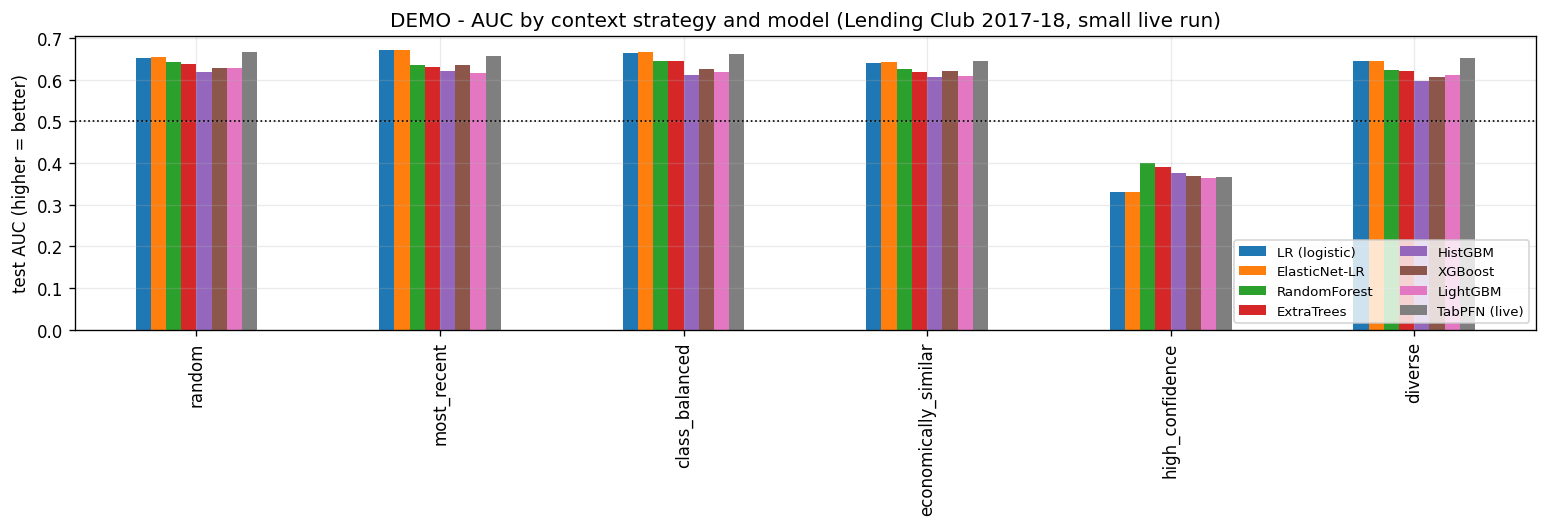

,LR (logistic),ElasticNet-LR,RandomForest,ExtraTrees,HistGBM,XGBoost,LightGBM,TabPFN (live)
random,0.652,0.654,0.642,0.638,0.617,0.627,0.628,0.667
most_recent,0.671,0.671,0.635,0.631,0.620,0.634,0.616,0.656
class_balanced,0.664,0.666,0.645,0.644,0.610,0.625,0.617,0.661
economically_similar,0.641,0.642,0.627,0.618,0.606,0.621,0.610,0.645
high_confidence,0.331,0.330,0.400,0.390,0.377,0.368,0.365,0.365
diverse,0.644,0.646,0.623,0.620,0.597,0.608,0.612,0.651


In [27]:
demo_auc = pd.DataFrame({s: {m: d[m]["AUC"] for m in d} for s, d in demo.items()}).T
if tabpfn_auc:
    demo_auc["TabPFN (live)"] = pd.Series(tabpfn_auc)

import matplotlib.cm as cm
colors = [cm.tab10(i % 10) for i in range(demo_auc.shape[1])]
ax = demo_auc.plot.bar(figsize=(13, 4.5), color=colors)
ax.axhline(0.5, color="k", ls=":", lw=1); ax.set_ylabel("test AUC (higher = better)")
ax.set_title("DEMO - AUC by context strategy and model (Lending Club 2017-18, small live run)")
ax.legend(loc="lower right", fontsize=8, ncol=2); plt.tight_layout(); plt.show()
demo_auc.round(3)

### Reading the demo

Two effects usually jump out even from this small live run:

1. **The choice of context matters.** `class_balanced` and `most_recent` land near the top;
   `high_confidence` sinks toward — or below — the 0.5 guessing line. Same models, same amount of
   data: only the *selection* of examples changed.
2. **The `high_confidence` trap is real and it hits everyone.** Because that context contains the
   sign-flipped signal we saw earlier, essentially every model — ordinary or foundation — scores near
   or below 0.5 on it. A "smart-sounding" heuristic actively hurt.

One honest caveat: with only 400 rows, one split, and one random seed, the demo is a *teaching*
slice, not the final word. In particular, at this tiny size the simple models can look as strong as
the foundation model. The numbers we actually *report* come from the full study next, which uses
larger contexts, several random seeds, a second dataset, and the second foundation model.

## 7. The full study: results at scale

Everything above ran live so you could see each step. The results below are loaded from the finished
research experiment, which is far larger than a notebook can run in a few minutes:

**2 datasets  x  5 time-splits  x  6 strategies  x  4 context sizes  x  up to 5 random seeds**, plus
the two heavy GPU foundation models **TabPFN** and **TabFM**.

First, TabPFN's average AUC for each time-split and strategy, at the full 1,024-row context. Higher is better; scan each row to see which strategy won for that split.

In [28]:
agg = pd.read_csv(STATS / "aggregate.csv")
best = agg[agg.n_requested == 1024]
table = best.pivot_table(index="split", columns="strategy", values="roc_auc_mean").round(3)
table

strategy,class_balanced,diverse,economically_similar,high_confidence,most_recent,random
split,,,,,,
fm_early,0.759,0.725,0.719,0.240,0.765,0.719
fm_late,0.793,0.748,0.717,0.283,0.749,0.729
lc_post_crisis,0.687,0.689,0.685,0.318,0.688,0.686
lc_pre_crisis,0.536,0.535,0.519,0.536,0.536,0.536
lc_recent,0.672,0.666,0.667,0.377,0.671,0.673


Does a bigger context always help? The curves below show AUC as the context grows from 128 to 1,024 rows, for each strategy, on the three Lending Club splits. Good strategies rise; `high_confidence` stays stuck near or below the 0.5 line no matter how many rows it is given.

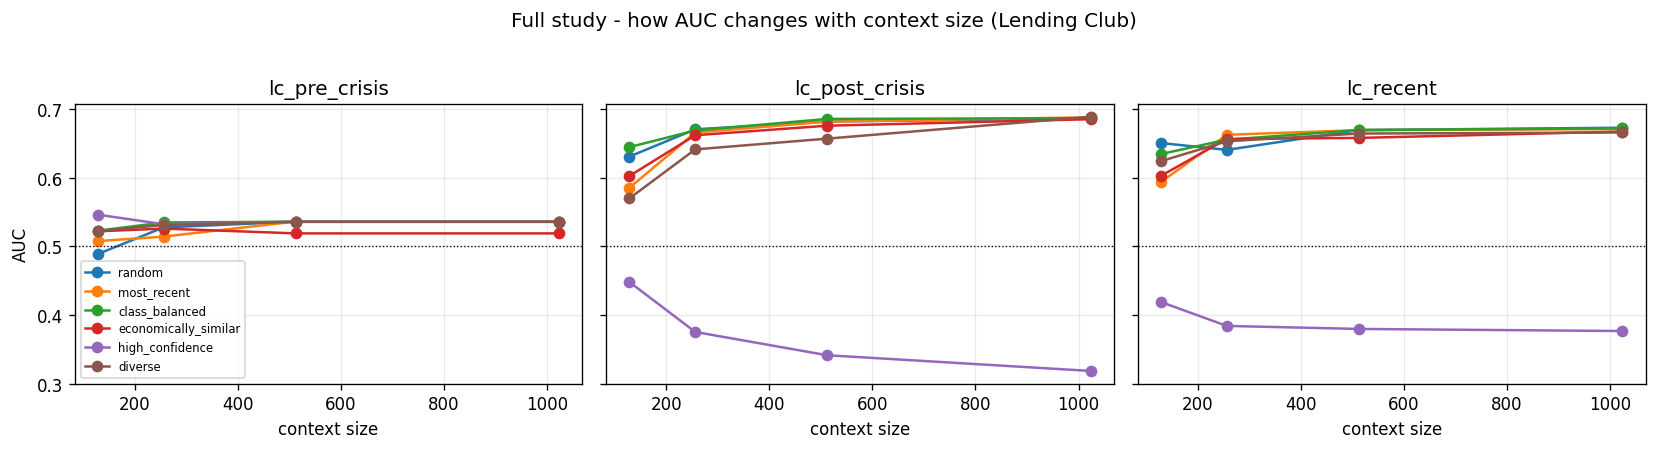

In [29]:
STRATS = ["random","most_recent","class_balanced","economically_similar","high_confidence","diverse"]
lc = agg[agg.dataset == "lending_club"]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for a, split in zip(ax, ["lc_pre_crisis","lc_post_crisis","lc_recent"]):
    sub = lc[lc.split == split]
    for s in STRATS:
        d = sub[sub.strategy == s].sort_values("n_requested")
        a.plot(d.n_requested, d.roc_auc_mean, marker="o", label=s)
    a.axhline(0.5, color="k", ls=":", lw=0.8); a.set_title(split); a.set_xlabel("context size")
ax[0].set_ylabel("AUC"); ax[0].legend(fontsize=7, loc="lower left")
fig.suptitle("Full study - how AUC changes with context size (Lending Club)", y=1.03)
plt.tight_layout(); plt.show()

### Do the two foundation models agree?

This is the key robustness check. For each context we compare four learners on identical data:
`TabPFN`, `TabFM` (the two foundation models), and `lr_context`, `xgb_context` (logistic regression
and XGBoost trained on that same context). If the two foundation models agree, the behavior is a
property of in-context learning in general, not of one specific model.

In [30]:
cm_df = pd.read_csv(STATS / "cross_model_4way.csv")
piv = cm_df.groupby(["dataset","split","strategy","model"]).roc_auc.mean().unstack("model")
piv = piv[[c for c in ["tabpfn","tabfm","lr_context","xgb_context"] if c in piv.columns]].round(3)
piv

model                                             tabpfn  tabfm  lr_context  \
dataset      split          strategy                                          
freddie_mac  fm_early       class_balanced         0.764  0.769       0.771   
                            diverse                0.726  0.662       0.717   
                            economically_similar   0.734  0.674       0.728   
                            high_confidence        0.236  0.236       0.240   
                            most_recent            0.773  0.730       0.756   
                            random                 0.734  0.674       0.728   
             fm_late        class_balanced         0.793  0.791       0.789   
                            diverse                0.747  0.717       0.703   
                            economically_similar   0.720  0.714       0.704   
                            high_confidence        0.281  0.299       0.248   
                            most_recent            0.751  0.738       0.761   
                            random                 0.708  0.693       0.713   
lending_club lc_post_crisis class_balanced         0.688  0.690       0.665   
                            diverse                0.692  0.692       0.660   
                            economically_similar   0.690  0.699       0.661   
                            high_confidence        0.312  0.313       0.331   
                            most_recent            0.691  0.700       0.658   
                            random                 0.691  0.698       0.655   
             lc_pre_crisis  class_balanced         0.545  0.546       0.497   
                            diverse                0.544  0.546       0.497   
                            economically_similar   0.523  0.534       0.476   
                            high_confidence        0.544  0.546       0.497   
                            most_recent            0.545  0.547       0.497   
                            random                 0.544  0.547       0.497   
             lc_recent      class_balanced         0.676  0.678       0.666   
                            diverse                0.669  0.675       0.646   
                            economically_similar   0.672  0.668       0.657   
                            high_confidence        0.374  0.472       0.333   
                            most_recent            0.674  0.670       0.653   
                            random                 0.679  0.674       0.658   

model                                             xgb_context  
dataset      split          strategy                           
freddie_mac  fm_early       class_balanced              0.729  
                            diverse                     0.670  
                            economically_similar        0.677  
                            high_confidence             0.271  
                            most_recent                 0.667  
                            random                      0.677  
             fm_late        class_balanced              0.770  
                            diverse                     0.663  
                            economically_similar        0.681  
                            high_confidence             0.279  
                            most_recent                 0.741  
                            random                      0.678  
lending_club lc_post_crisis class_balanced              0.637  
                            diverse                     0.644  
                            economically_similar        0.650  
                            high_confidence             0.363  
                            most_recent                 0.656  
                            random                      0.636  
             lc_pre_crisis  class_balanced              0.524  
                            diverse                     0.523  
                            economically_similar        0.518  

In [31]:
g = piv.reset_index()
viable = g[(g.strategy != "high_confidence") & (g.split != "lc_pre_crisis")]
hc = g[g.strategy == "high_confidence"]
print(f"1) TabPFN vs TabFM agreement : correlation = {g.tabpfn.corr(g.tabfm):.3f}, mean |difference| = {(g.tabpfn-g.tabfm).abs().mean():.3f} AUC")
print(f"2) high_confidence average   : TabPFN = {hc.tabpfn.mean():.3f}, TabFM = {hc.tabfm.mean():.3f}  (both below 0.5 -> the trap inverts BOTH models)")
print(f"3) Foundation beats plain LR : TabFM wins in {(viable.tabfm>viable.lr_context).mean()*100:.0f}% of sensible cells (+{(viable.tabfm-viable.lr_context).mean():.3f} AUC on average)")

1) TabPFN vs TabFM agreement : correlation = 0.984, mean |difference| = 0.016 AUC
2) high_confidence average   : TabPFN = 0.349, TabFM = 0.373  (both below 0.5 -> the trap inverts BOTH models)
3) Foundation beats plain LR : TabFM wins in 65% of sensible cells (+0.003 AUC on average)


Each dot is one split-and-strategy combination. If the two models agreed perfectly, every dot would land on the dashed diagonal. They very nearly do — including the points in the bottom-left corner, below 0.5, where both models fall into the `high_confidence` trap together.

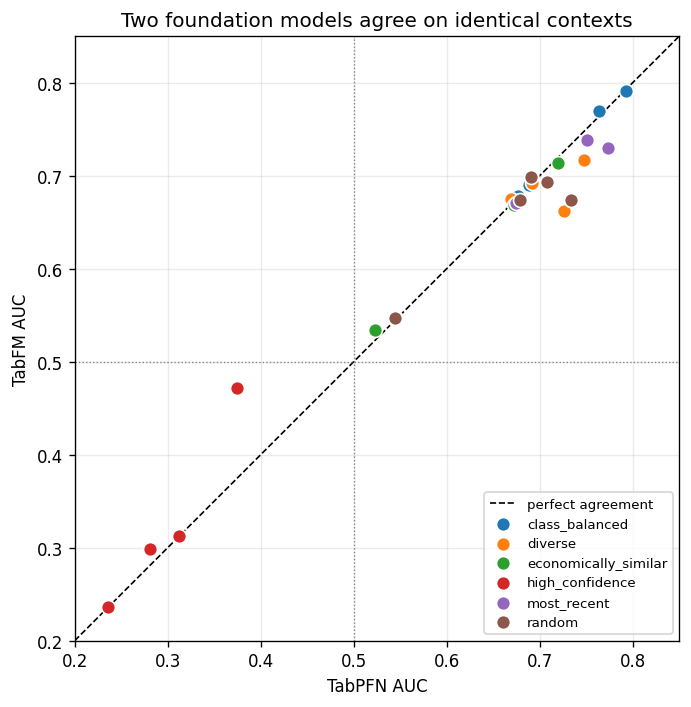

In [32]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0.2, 0.85], [0.2, 0.85], "k--", lw=1, label="perfect agreement")
ax.axhline(0.5, color="grey", ls=":", lw=0.8); ax.axvline(0.5, color="grey", ls=":", lw=0.8)
for i, s in enumerate(sorted(g.strategy.unique())):
    sub = g[g.strategy == s]
    ax.scatter(sub.tabpfn, sub.tabfm, s=70, color=plt.get_cmap("tab10")(i), label=s, edgecolor="white", zorder=3)
ax.set(xlabel="TabPFN AUC", ylabel="TabFM AUC", xlim=(0.2, 0.85), ylim=(0.2, 0.85), aspect="equal",
       title="Two foundation models agree on identical contexts")
ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()

### The honest headline: parity, not magic

The most important comparison is against a *tuned* XGBoost trained on **everything** in the pool
(13,000 to 100,000 rows). Can a curated 1,024-row context keep up with a strong conventional model
that used a hundred times more data?

The plot shows, for each dataset and split, the AUC gap between the best curated foundation-model
context and the tuned full-data XGBoost. A dot near zero, with its error bar crossing the zero line,
means **a statistical tie**: the tiny curated context matched the data-hungry model. That is the real
result — remarkable data efficiency, but not a free lunch that beats everything.

,dataset,split,best_strategy,gap_auc_mean,gap_ci95_lo,gap_ci95_hi,significant
0,freddie_mac,fm_early,most_recent,0.010,-0.009,0.031,False
2,freddie_mac,fm_late,class_balanced,0.002,-0.011,0.012,False
4,lending_club,lc_post_crisis,diverse,0.004,-0.005,0.018,False
6,lending_club,lc_pre_crisis,most_recent,0.007,-0.041,0.064,False
8,lending_club,lc_recent,random,-0.014,-0.023,-0.005,True


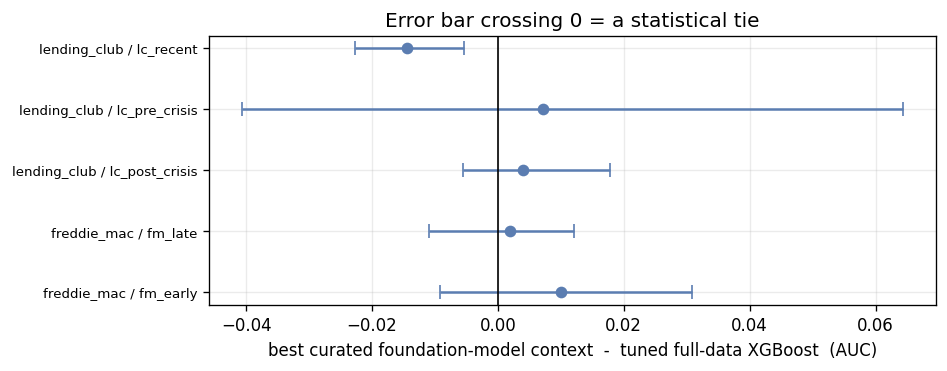

In [33]:
gaps = pd.read_csv(STATS / "gaps.csv")
tuned = gaps[gaps.baseline == "xgboost_tuned"].copy()
display(tuned[["dataset","split","best_strategy","gap_auc_mean","gap_ci95_lo","gap_ci95_hi","significant"]].round(3))

fig, ax = plt.subplots(figsize=(8, 3.2))
lbl = tuned.dataset + " / " + tuned.split
lo, hi, mid = tuned.gap_ci95_lo, tuned.gap_ci95_hi, tuned.gap_auc_mean
ax.errorbar(mid, range(len(tuned)), xerr=[mid-lo, hi-mid], fmt="o", color=BLUE, capsize=4)
ax.axvline(0, color="k", lw=1); ax.set_yticks(range(len(tuned))); ax.set_yticklabels(lbl, fontsize=8)
ax.set_xlabel("best curated foundation-model context  -  tuned full-data XGBoost  (AUC)")
ax.set_title("Error bar crossing 0 = a statistical tie")
plt.tight_layout(); plt.show()

## 8. What we learned

1. **The choice of context matters.** With the same model and the same amount of data, good
   selection strategies (`class_balanced`, `most_recent`) clearly beat poor ones (`high_confidence`).
   *Which* examples you show a model can matter as much as how many.
2. **A clever-sounding heuristic can backfire.** `high_confidence` selects a slice of data where the
   relationship between features and default flips sign, so predictions come out upside-down, with
   AUC below 0.5.
3. **Reading can rival training.** A foundation model that merely reads a well-chosen context often
   matches, and on sensible splits beats, an ordinary model trained on that same context.
4. **The findings reproduce on a second model.** TabPFN and TabFM agree to within about 0.016 AUC per
   case, and the `high_confidence` trap inverts both. So these are properties of *context curation*,
   not accidents of one model.
5. **Parity, not magic.** A curated 1,024-row context ties a tuned XGBoost trained on far more data.
   That is impressive data efficiency, and an honest result rather than an inflated claim.

**Limitations, stated plainly.** The foundation models are capped near 1,024 rows, so they cannot
read all of history at once. The `economically_similar` strategy peeks at aggregate statistics of the
test period to choose a context, which is valid for this study but would need care in a live
deployment. And the live demo in this notebook is a single small slice; the reported conclusions come
from the full multi-seed study in Section 7.

**Where a curious reader could go next.** Re-run Section 6 with a different random `SEED`, or change
`POOL_YEARS` and `TEST_YEARS` in Section 2 to a different pair of periods, and see whether the same
strategies keep winning.